In [1]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

project_path = "/content/drive/MyDrive/Fraud_Detection"

os.makedirs(project_path, exist_ok=True)

print("Project folder ready at:", project_path)

Project folder ready at: /content/drive/MyDrive/Fraud_Detection


In [4]:
# STEP 1: INSTALL & IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [8]:
#STEP 2: Load the dataset
data_path = os.path.join(project_path, "newcreditcard.csv")
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['Class'].value_counts()}")

Dataset shape: (284807, 31)
Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [9]:
# STEP 3: SEPARATE FEATURES AND TARGET
# Dropping 'Class' (target) and 'Time' if it is not useful

X = df.drop(['Class', 'Time'], axis=1)
y = df['Class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 29)
Target shape: (284807,)


In [10]:
# STEP 4: TRAIN TEST SPLIT
# 80% training
# 20% testing
# stratify ensures fraud ratio remains similar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (227845, 29)
Test set: (56962, 29)


In [11]:
# STEP 5: SCALE FEATURES
# Neural networks perform better with normalized data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")

Scaling completed


In [12]:
# STEP 6: HANDLE CLASS IMBALANCE WITH SMOTE
# SMOTE creates synthetic fraud samples
# This balances the training dataset

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_resampled))

Before SMOTE: [227451    394]
After SMOTE: [227451 227451]


In [13]:
# STEP 7: BUILD NEURAL NETWORK MODEL
# Architecture:
# Input → Dense → Dropout → Dense → Dropout → Output

model = Sequential([

    Dense(64, activation='relu', input_shape=(X_train_resampled.shape[1],)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# STEP 8: TRAIN MODEL
# EarlyStopping stops training if validation stops improving

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(

    X_train_resampled,
    y_train_resampled,

    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]

)

Epoch 1/50
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - accuracy: 0.9685 - loss: 0.0845 - val_accuracy: 0.9994 - val_loss: 0.0067
Epoch 2/50
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.9967 - loss: 0.0124 - val_accuracy: 0.9993 - val_loss: 0.0046
Epoch 3/50
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - accuracy: 0.9975 - loss: 0.0096 - val_accuracy: 0.9997 - val_loss: 0.0040
Epoch 4/50
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - accuracy: 0.9979 - loss: 0.0082 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 5/50
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - accuracy: 0.9983 - loss: 0.0070 - val_accuracy: 0.9994 - val_loss: 0.0028
Epoch 6/50
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.9984 - loss: 0.0065 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 7/50
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.9986 - loss: 0.0059 - val_accuracy: 0.9984 - val_loss: 0.0046
Epoch 8/50
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 

In [15]:

# STEP 9: MODEL EVALUATION
# Predict fraud probabilities

y_pred_prob = model.predict(X_test_scaled)

y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Accuracy: 0.9987886661282961
Precision: 0.6074074074074074
Recall: 0.8367346938775511
F1 Score: 0.703862660944206
ROC-AUC: 0.9699235842339188


In [16]:
from sklearn.metrics import classification_report
# CLASSIFICATION REPORT
# Shows precision, recall, f1-score for each class

print("Classification Report:\n")

print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.61      0.84      0.70        98

    accuracy                           1.00     56962
   macro avg       0.80      0.92      0.85     56962
weighted avg       1.00      1.00      1.00     56962



In [24]:
y_pred_prob = model.predict(X_test_scaled)

y_pred = (y_pred_prob > 0.5).astype(int)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [26]:
from sklearn.metrics import classification_report

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for t in thresholds:

    print("\nThreshold:", t)

    y_pred = (y_pred_prob > t).astype(int)

    print(classification_report(y_test, y_pred))


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.56      0.84      0.67        98

    accuracy                           1.00     56962
   macro avg       0.78      0.92      0.84     56962
weighted avg       1.00      1.00      1.00     56962


Threshold: 0.4
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.59      0.84      0.69        98

    accuracy                           1.00     56962
   macro avg       0.79      0.92      0.85     56962
weighted avg       1.00      1.00      1.00     56962


Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.61      0.84      0.70        98

    accuracy                           1.00     56962
   macro avg       0.80      0.92      0.85     56962
weighted avg       1.00   

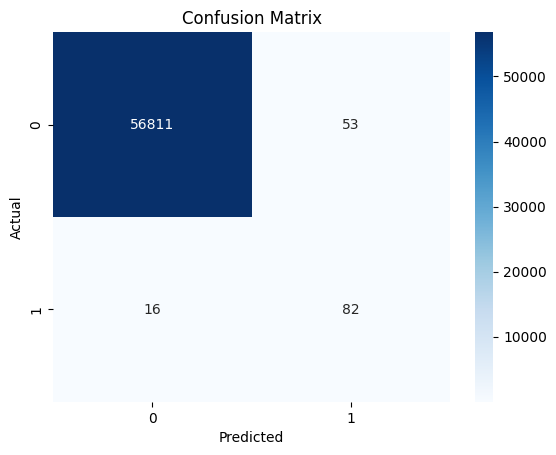

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

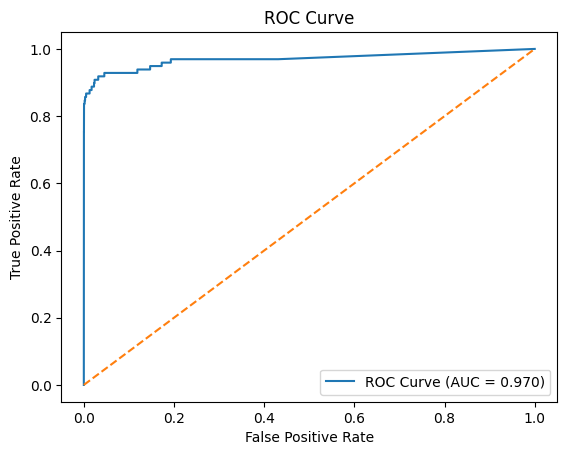

In [18]:
# STEP 10: ROC CURVE

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure()

plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.3f)" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [23]:
# STEP: SAVE MODEL AND SCALER WITH UNIQUE NAMES
# This avoids overwriting previous models in Google Drive

model_path = "/content/drive/MyDrive/Fraud Detection/fraud_nn_smote_v1.h5"
scaler_path = "/content/drive/MyDrive/Fraud Detection/scaler_smote_v1.pkl"

model.save(model_path)

with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully")

Model and scaler saved successfully


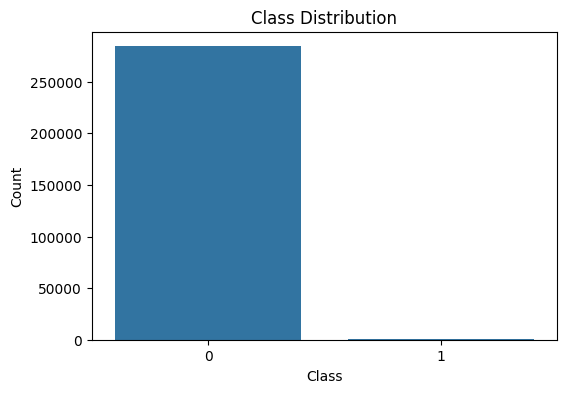

In [20]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

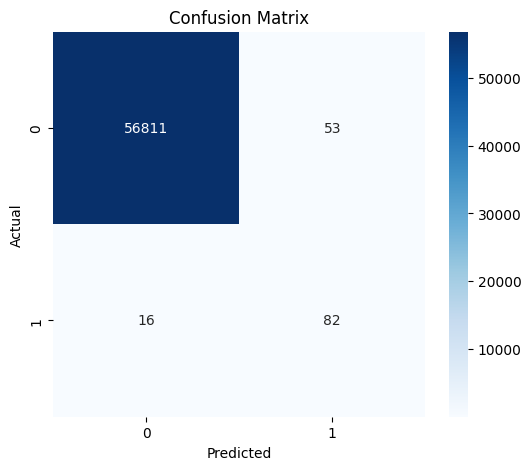

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**Precision-Recall Curve**

For imbalanced datasets, this is sometimes better than ROC.

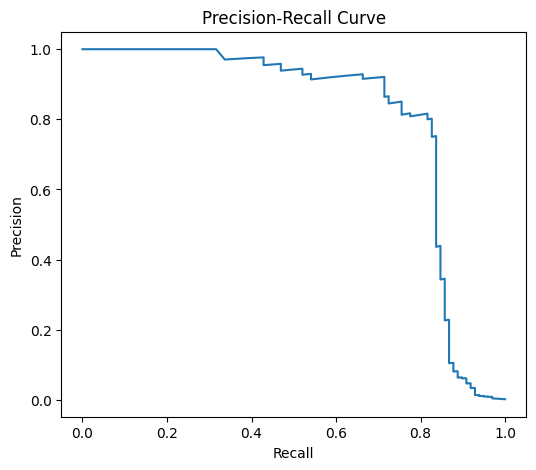

In [22]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,5))

plt.plot(recall_vals, precision_vals)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()